In [55]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Resolve repo root whether running from repo root or algorithm/
repo_root = Path.cwd()
if not (repo_root / 'algorithm').exists():
    repo_root = repo_root.parent

algo_dir = repo_root / 'algorithm'
sys.path.insert(0, str(algo_dir))

from data_io import read_data
from distributions import fit_shifted_exponential, fit_lognormal

# Config
dataset_name = 'alpaca'  # or 'rlhf'
rm_name = 'mistral_rm'
llm_names = ['gemma2_9b', 'llama3.1_8b', 'mistral_7b', 'qwen2.5_7b']
indices = [8, 18, 28, 38]
delta = 0.05
q = np.linspace(0.01, 0.99, 200)

if dataset_name == 'alpaca':
    input_folder = repo_root / 'dataset' / 'alpaca'
elif dataset_name == 'rlhf':
    input_folder = repo_root / 'dataset' / 'hh_rlhf'
else:
    raise ValueError(f'Unknown dataset_name: {dataset_name}')


In [56]:
def _qq_shifted_exponential(rewards, delta, q):
    exp_rewards = np.exp(rewards)
    params = fit_shifted_exponential(exp_rewards, exp_rewards.size, delta)
    tail = exp_rewards[exp_rewards >= np.median(exp_rewards)]
    emp = np.quantile(tail, q)
    theo = params['loc'] - params['scale'] * np.log(1 - q)
    return theo, emp


def _qq_lognormal(rewards, delta, q):
    exp_rewards = np.exp(rewards)
    params = fit_lognormal(rewards, rewards.size, delta)
    emp = np.quantile(exp_rewards, q)
    theo = np.exp(params['mu'] + params['sigma'] * norm.ppf(q))
    return theo, emp


In [57]:
def _plot_grid(title, qq_builder):
    fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=False, sharey=False)
    for row, llm_name in enumerate(llm_names):
        data = read_data(str(input_folder), llm_name)
        for col, idx in enumerate(indices):
            ax = axes[row, col]
            if idx >= len(data):
                ax.set_axis_off()
                ax.set_title(f'idx {idx} out of range')
                continue
            prompt = data[idx]
            rewards = np.array([g[f'{rm_name}_reward'] for g in prompt['generations']], dtype=float)
            theo, emp = qq_builder(rewards, delta, q)
            ax.scatter(theo, emp, s=10, alpha=0.6)
            min_val = min(np.min(theo), np.min(emp))
            max_val = max(np.max(theo), np.max(emp))
            ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
            ax.grid(True, alpha=0.3)
            if row == 0:
                ax.set_title(f'idx {idx}', fontsize=10)
            if col == 0:
                ax.set_ylabel(llm_name, fontsize=10)
    fig.suptitle(f'{title} | dataset={dataset_name} rm={rm_name}', y=1.02)
    plt.tight_layout()
    plt.show()


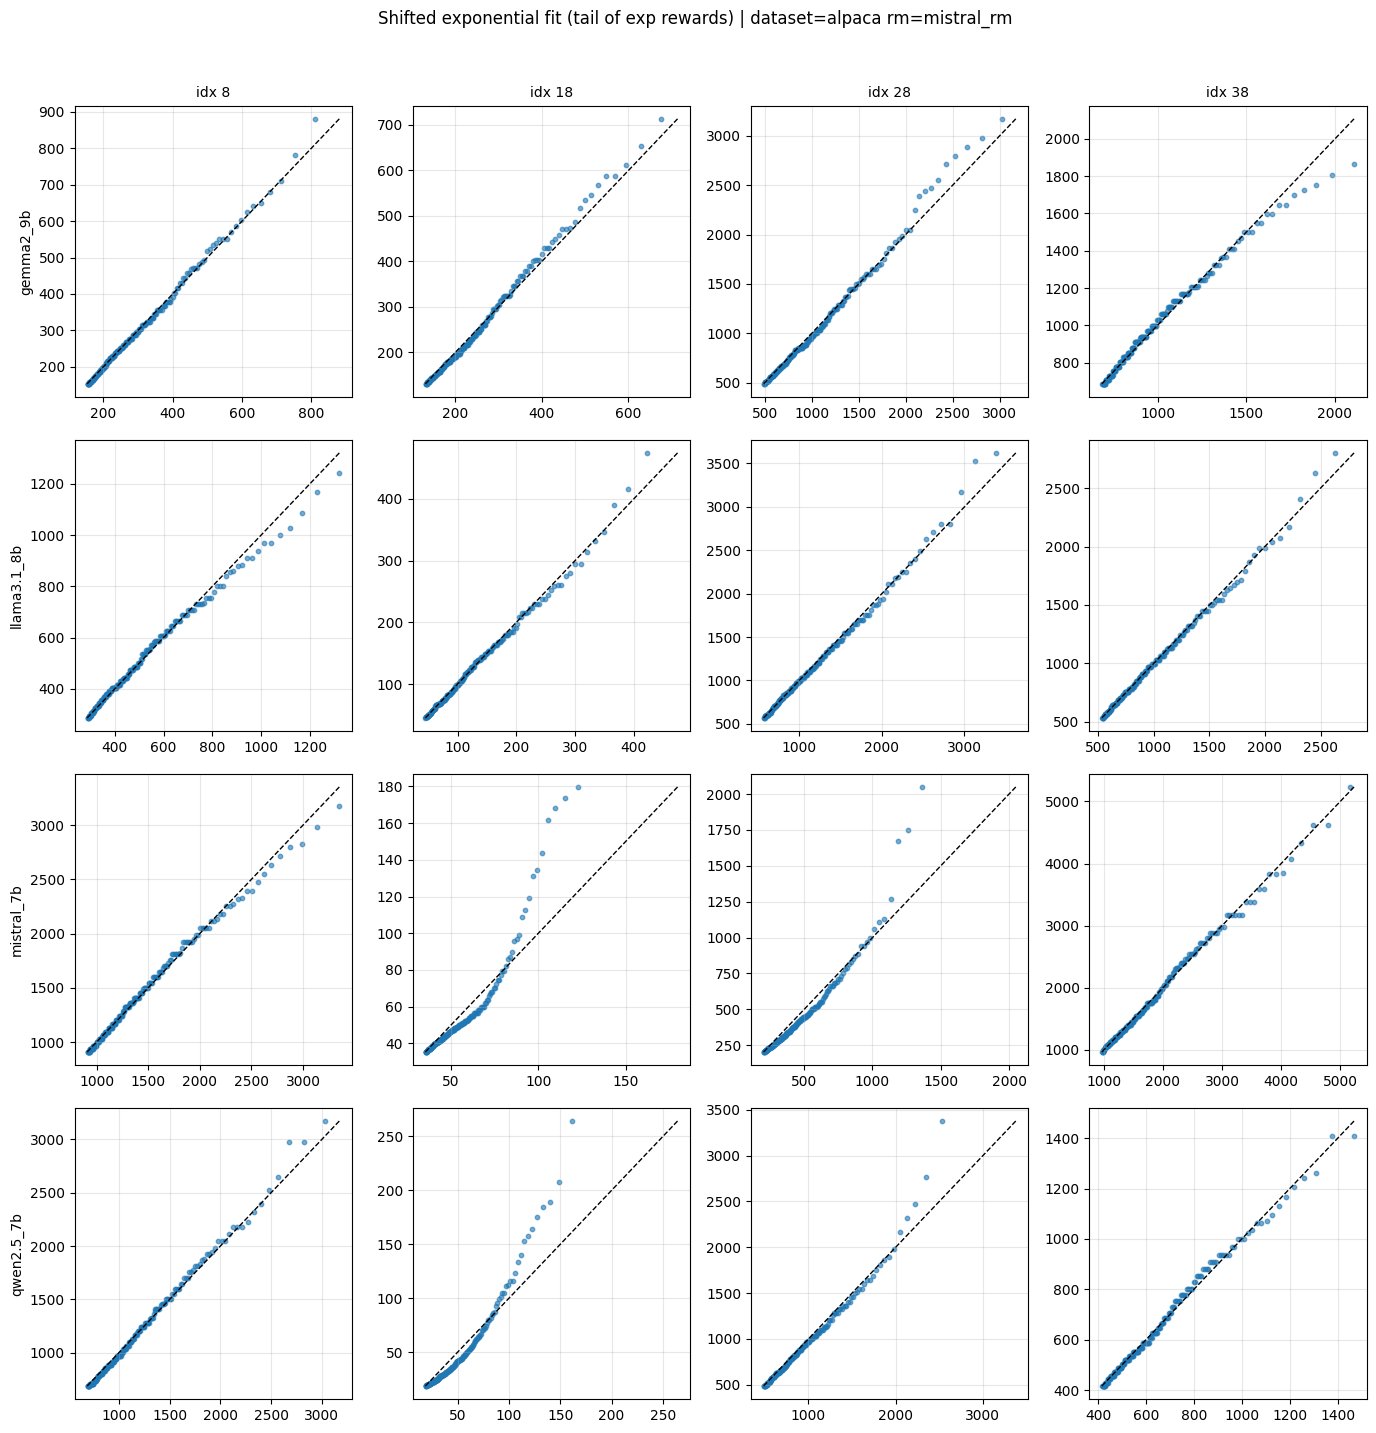

In [58]:
_plot_grid('Shifted exponential fit (tail of exp rewards)', _qq_shifted_exponential)


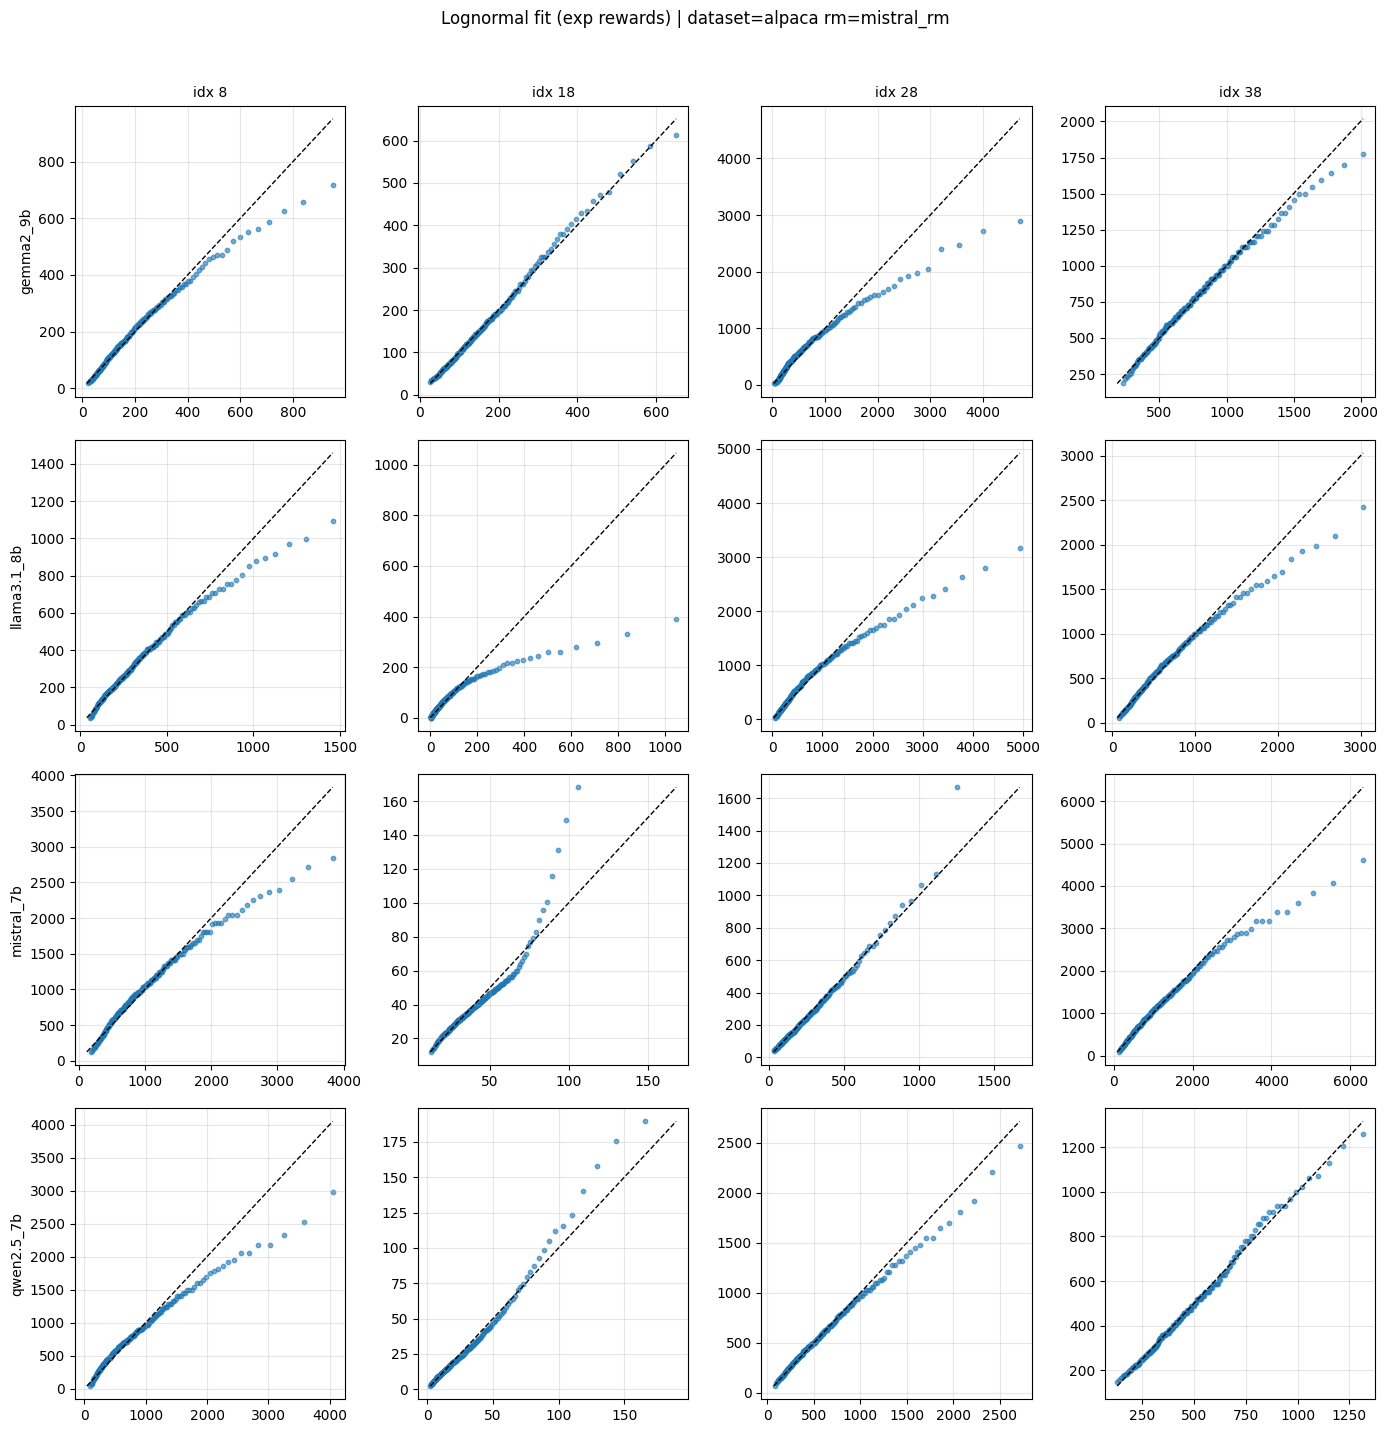

In [59]:
_plot_grid('Lognormal fit (exp rewards)', _qq_lognormal)
